# Stability and Ablation Notebook

This notebook is designed to fill **deficiency D001** for the dissertation. It uses the same synthetic Case 1 workflow and reporting style as the existing notebooks in `notebooks/`, but adds the missing stability-first evaluation package for **RQ1**.


## Experiment Design

The notebook produces four deliverables tied directly to D001:

1. **Repeated-resample stability summaries** using multiple synthetic resamples with fixed ground-truth lags.
2. **Lag-fidelity metrics** using the known true feature-lag set.
3. **Stage-wise ablations** across:
   - raw continuous L1-logistic,
   - rectified L1-logistic,
   - rectified prefix-rule compression (`m`-of-`k`) as a lightweight pipeline endpoint.
4. **Runtime scaling under lag expansion** by increasing the history window `H` and measuring rectification and model-fit time.

The main stability study uses the stronger external-CV sklearn path from the local scripts. The lag-scaling section uses the lighter local `build_model(...)` path to keep the timing sweep practical.


In [1]:
from __future__ import annotations

import importlib.util
import itertools
import math
import re
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from sklearn.metrics import precision_recall_curve, roc_auc_score

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import display
except Exception:
    display = None

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
if sns is not None:
    sns.set(style="whitegrid")


In [2]:
def _find_repo_root() -> Path:
    anchors = [Path.cwd().resolve()]
    if "__file__" in globals():
        anchors.insert(0, Path(__file__).resolve().parent)
    for anchor in anchors:
        for candidate in (anchor, *anchor.parents):
            if (candidate / "scripts").is_dir() and (candidate / "notebooks").is_dir():
                return candidate
    raise FileNotFoundError("Could not locate the dissertation repository root.")


def _load_module(name: str, path: Path):
    spec = importlib.util.spec_from_file_location(name, str(path))
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


REPO_ROOT = _find_repo_root()
SCRIPTS_DIR = REPO_ROOT / "scripts"
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
FIGURES_DIR = NOTEBOOKS_DIR / "Figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR = NOTEBOOKS_DIR / "runs_new" / "stability_ablation"
RUN_DIR.mkdir(parents=True, exist_ok=True)

syn = _load_module("stability_syn", SCRIPTS_DIR / "sensor_generate - commented.py")
skcase = _load_module("stability_skcase", SCRIPTS_DIR / "case_1_simple_script_scikit_fast_v6.py")

print("Repository root:", REPO_ROOT)
print("Figures directory:", FIGURES_DIR)
print("Run directory:", RUN_DIR)


Repository root: C:\Users\jason\ODU\dissertation
Figures directory: C:\Users\jason\ODU\dissertation\notebooks\Figures
Run directory: C:\Users\jason\ODU\dissertation\notebooks\runs_new\stability_ablation


In [3]:
BASE_CONFIG = dict(
    num_examples=1800,
    N=100,
    S=40,
    R=(5, 6, 9, 10, 15, 25, 30),
    AB=("a", "a", "b", "b", "a", "b", "n"),
    gp=(1, 1, 1, 1, 1, 1, 1),
    H=10,
    train_fr=0.70,
    disp=(
        0, 0, 0, 0, 10, 6, 0, 10, 1, 0,
        0, 0, 2, 0, 5, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 0, 0, 7,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    ),
    thresh_a=0.30,
    thresh_b=0.65,
    tr_frac=0.25,
    pos_tol=5e-3,
    max_cycle_iters=10,
    max_thresh_iters=24,
    verbose=False,
)

STABILITY_SEEDS = [1234, 1235, 1236]
SUPPORT_K = len(BASE_CONFIG["R"])
TRUE_FEATURES = [f"V{r}TM{BASE_CONFIG['disp'][r - 1]}" for r in BASE_CONFIG["R"]]
MODEL_KW = dict(cv=3, cs=7, c_lo=-3, c_hi=3, solver="saga", tol=1e-3, max_iter=1200, cv_rule="1se")

LAG_SCALING_H = [10, 15, 20]
LAG_SCALING_SEED = 1234
SCALE_CONFIG = dict(BASE_CONFIG)
SCALE_CONFIG["num_examples"] = 1000
SCALE_MODEL_KW = dict(cv=3, cs=5, solver="saga", tol=1e-3, max_iter=800, random_state=LAG_SCALING_SEED)

OVERWRITE_CACHE = False

config_view = pd.DataFrame(
    [
        {"Parameter": "True features", "Value": ", ".join(TRUE_FEATURES)},
        {"Parameter": "Support K", "Value": SUPPORT_K},
        {"Parameter": "Stability seeds", "Value": ", ".join(map(str, STABILITY_SEEDS))},
        {"Parameter": "Lag scaling H values", "Value": ", ".join(map(str, LAG_SCALING_H))},
        {"Parameter": "Main dataset size", "Value": BASE_CONFIG["num_examples"]},
    ]
)
if display is not None:
    display(config_view)
else:
    print(config_view.to_string(index=False))


,Parameter,Value
0,True features,"V5TM10, V6TM6, V9TM1, V10TM0, V15TM5, V25TM3, ..."
1,Support K,7
2,Stability seeds,"1234, 1235, 1236"
3,Lag scaling H values,"10, 15, 20"
4,Main dataset size,1800


In [4]:
def parse_feature(name: str):
    match = re.match(r"^V(\d+)TM(\d+)$", str(name))
    if not match:
        return None
    return int(match.group(1)), int(match.group(2))


def decode_support(serialized: str) -> list[str]:
    if not isinstance(serialized, str) or not serialized:
        return []
    return [part for part in serialized.split("|") if part]


def youden_from_pred(y_true, y_pred) -> float:
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    tp = int(np.sum(y_true & y_pred))
    fn = int(np.sum(y_true & ~y_pred))
    fp = int(np.sum(~y_true & y_pred))
    tn = int(np.sum(~y_true & ~y_pred))
    tpr = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    return tpr + tnr - 1.0


def max_f1(y_true, score) -> float:
    prec, rec, _ = precision_recall_curve(np.asarray(y_true).astype(int), np.asarray(score, dtype=float))
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
    return float(np.nanmax(f1))


def safe_auc(y_true, score) -> float:
    y_arr = np.asarray(y_true).astype(int)
    if len(np.unique(y_arr)) < 2:
        return float("nan")
    return float(roc_auc_score(y_arr, np.asarray(score, dtype=float)))


def topk_features(pipe, feature_names: list[str], k: int):
    beta = skcase.coefficient_series_only(pipe, feature_names)
    beta = beta.sort_values(key=np.abs, ascending=False)
    top = beta.index[: min(k, len(beta))].tolist()
    return top, beta


def lag_metrics(selected: list[str], truth: list[str], tol: int = 0) -> tuple[float, float, float]:
    selected_parsed = [item for item in (parse_feature(x) for x in selected) if item is not None]
    truth_parsed = [item for item in (parse_feature(x) for x in truth) if item is not None]
    matched_truth = set()
    hits = 0
    for variable, lag in selected_parsed:
        for j, (truth_variable, truth_lag) in enumerate(truth_parsed):
            if j in matched_truth:
                continue
            if variable == truth_variable and abs(lag - truth_lag) <= tol:
                matched_truth.add(j)
                hits += 1
                break
    precision = hits / max(len(selected_parsed), 1)
    recall = hits / max(len(truth_parsed), 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    return precision, recall, f1


def support_jaccard(a: list[str], b: list[str]) -> float:
    a_set, b_set = set(a), set(b)
    return len(a_set & b_set) / max(len(a_set | b_set), 1)


def support_jaccard_near(a: list[str], b: list[str], tol: int = 1) -> float:
    a_parsed = [item for item in (parse_feature(x) for x in a) if item is not None]
    b_parsed = [item for item in (parse_feature(x) for x in b) if item is not None]
    matched_b = set()
    hits = 0
    for variable_a, lag_a in a_parsed:
        for j, (variable_b, lag_b) in enumerate(b_parsed):
            if j in matched_b:
                continue
            if variable_a == variable_b and abs(lag_a - lag_b) <= tol:
                matched_b.add(j)
                hits += 1
                break
    return hits / max(len(a_parsed) + len(b_parsed) - hits, 1)


def build_rule_from_rectified(pipe, rt_train: pd.DataFrame, max_k: int = 20, rel_tol: float = 0.005) -> dict:
    X = rt_train.drop(columns=["INDC"])
    y = rt_train["INDC"].astype(bool).to_numpy()
    beta = skcase.coefficient_series_only(pipe, X.columns.tolist())
    beta = beta[beta != 0].sort_values(key=np.abs, ascending=False)
    beta = beta.iloc[: min(max_k, len(beta))]
    if beta.empty:
        return {"k": 0, "m": 1, "features": [], "directions": np.array([], dtype=int)}

    directions = np.sign(beta.to_numpy())
    directions[directions == 0] = 1
    support = (X[beta.index].to_numpy(dtype=int) * directions) > 0

    candidates = []
    for k in range(1, len(beta) + 1):
        counts = support[:, :k].sum(axis=1)
        best_m = 1
        best_j = -np.inf
        for m in range(1, k + 1):
            pred = counts >= m
            j_value = youden_from_pred(y, pred)
            if (j_value > best_j) or (math.isclose(j_value, best_j) and m < best_m):
                best_m = m
                best_j = j_value
        candidates.append((k, best_m, best_j))

    best_j = max(row[2] for row in candidates)
    eligible = [row for row in candidates if row[2] >= best_j - rel_tol]
    k_pick, m_pick, _ = min(eligible, key=lambda row: (row[0], row[1]))
    return {
        "k": int(k_pick),
        "m": int(m_pick),
        "features": beta.index[:k_pick].tolist(),
        "directions": directions[:k_pick],
    }


def apply_rule(rule: dict, rt_frame: pd.DataFrame):
    if not rule["features"]:
        pred = np.zeros(len(rt_frame), dtype=bool)
        score = np.zeros(len(rt_frame), dtype=float)
        return pred, score
    X = rt_frame[rule["features"]].to_numpy(dtype=int)
    support = (X * np.asarray(rule["directions"])) > 0
    counts = support.sum(axis=1)
    pred = counts >= int(rule["m"])
    score = counts / max(int(rule["k"]), 1)
    return pred, score


def format_mean_std(df: pd.DataFrame, metrics: list[str], group_col: str = "method") -> pd.DataFrame:
    grouped = df.groupby(group_col)[metrics].agg(["mean", "std"])
    rows = []
    for method, values in grouped.iterrows():
        row = {"method": method}
        for metric in metrics:
            mean_value = values[(metric, "mean")]
            std_value = values[(metric, "std")]
            row[metric] = f"{mean_value:.3f} +/- {std_value:.3f}"
        rows.append(row)
    return pd.DataFrame(rows)


def support_frequency_grid(supports: list[list[str]], n_variables: int, h: int) -> np.ndarray:
    grid = np.zeros((n_variables, h + 1), dtype=float)
    if not supports:
        return grid
    for support in supports:
        for feature in support:
            parsed = parse_feature(feature)
            if parsed is None:
                continue
            variable, lag = parsed
            if 1 <= variable <= n_variables and 0 <= lag <= h:
                grid[variable - 1, lag] += 1
    return grid / len(supports)


## Main Stability / Fidelity / Ablation Study

The main study uses repeated synthetic resamples with fixed ground-truth lags. For each seed, the notebook:

1. generates a synthetic Case 1 dataset,
2. rectifies it using training-only limits,
3. fits raw and rectified sparse logistic baselines,
4. derives a lightweight prefix-rule (`m`-of-`k`) from the rectified model,
5. logs discrimination, lag fidelity, support size, and timing.


In [5]:
def run_one_seed(seed: int, config: dict, support_k: int, model_kw: dict) -> list[dict]:
    cfg = dict(config)
    cfg["rseed"] = int(seed)

    t0 = time.perf_counter()
    full_df, train_df, test_df = syn.generate_synthetic_dataset_nexamples(**cfg)
    t_generate = time.perf_counter() - t0

    groups = skcase.organize(train_df)
    t1 = time.perf_counter()
    rt_train, limits = skcase.rectify_fast(train_df, groups, limits=None, sdfilter=3.0, snap=0.001)
    rt_test, _ = skcase.rectify_fast(test_df, groups, limits=limits, sdfilter=3.0, snap=0.001)
    t_rectify = time.perf_counter() - t1

    raw_train = train_df[[c for c in train_df.columns if c not in skcase.EXCLUDE_COLS]]
    raw_test = test_df[[c for c in test_df.columns if c not in skcase.EXCLUDE_COLS]]

    records = []

    t2 = time.perf_counter()
    raw_pipe, _ = skcase.sklearn_build_raw_external_cv(
        raw_train,
        random_state=seed,
        **model_kw,
    )
    t_raw_fit = time.perf_counter() - t2
    raw_prob, raw_y, raw_auc, _ = skcase.evaluate(raw_pipe, raw_test)
    raw_support, raw_beta = topk_features(raw_pipe, raw_train.drop(columns=["INDC"]).columns.tolist(), support_k)
    p0, r0, f0 = lag_metrics(raw_support, TRUE_FEATURES, tol=0)
    p1, r1, f1 = lag_metrics(raw_support, TRUE_FEATURES, tol=1)
    records.append(
        dict(
            seed=seed,
            method="raw",
            selected_features="|".join(raw_support),
            n_selected=len(raw_support),
            nonzero_total=int((raw_beta != 0).sum()),
            auc_test=float(raw_auc),
            j_test=float(youden_from_pred(raw_y, raw_prob >= 0.5)),
            f1max_test=float(max_f1(raw_y, raw_prob)),
            precision_exact=float(p0),
            recall_exact=float(r0),
            f1_exact=float(f0),
            precision_near=float(p1),
            recall_near=float(r1),
            f1_near=float(f1),
            t_generate=float(t_generate),
            t_rectify=float(t_rectify),
            t_fit=float(t_raw_fit),
            t_stage=float(t_raw_fit),
        )
    )

    t3 = time.perf_counter()
    rect_pipe, _ = skcase.sklearn_build_rectified_external_cv(
        rt_train,
        random_state=seed,
        **model_kw,
    )
    t_rect_fit = time.perf_counter() - t3
    rect_prob, rect_y, rect_auc, _ = skcase.evaluate(rect_pipe, rt_test)
    rect_support, rect_beta = topk_features(rect_pipe, rt_train.drop(columns=["INDC"]).columns.tolist(), support_k)
    p0, r0, f0 = lag_metrics(rect_support, TRUE_FEATURES, tol=0)
    p1, r1, f1 = lag_metrics(rect_support, TRUE_FEATURES, tol=1)
    records.append(
        dict(
            seed=seed,
            method="rectified",
            selected_features="|".join(rect_support),
            n_selected=len(rect_support),
            nonzero_total=int((rect_beta != 0).sum()),
            auc_test=float(rect_auc),
            j_test=float(youden_from_pred(rect_y, rect_prob >= 0.5)),
            f1max_test=float(max_f1(rect_y, rect_prob)),
            precision_exact=float(p0),
            recall_exact=float(r0),
            f1_exact=float(f0),
            precision_near=float(p1),
            recall_near=float(r1),
            f1_near=float(f1),
            t_generate=float(t_generate),
            t_rectify=float(t_rectify),
            t_fit=float(t_rect_fit),
            t_stage=float(t_rectify + t_rect_fit),
        )
    )

    t4 = time.perf_counter()
    rule = build_rule_from_rectified(rect_pipe, rt_train, max_k=20, rel_tol=0.005)
    rule_pred, rule_score = apply_rule(rule, rt_test)
    t_rule = time.perf_counter() - t4
    rule_y = rt_test["INDC"].astype(bool).to_numpy()
    p0, r0, f0 = lag_metrics(rule["features"], TRUE_FEATURES, tol=0)
    p1, r1, f1 = lag_metrics(rule["features"], TRUE_FEATURES, tol=1)
    records.append(
        dict(
            seed=seed,
            method="rule",
            selected_features="|".join(rule["features"]),
            n_selected=int(rule["k"]),
            nonzero_total=int(rule["k"]),
            rule_m=int(rule["m"]),
            auc_test=float(safe_auc(rule_y, rule_score)),
            j_test=float(youden_from_pred(rule_y, rule_pred)),
            f1max_test=float(max_f1(rule_y, rule_score)),
            precision_exact=float(p0),
            recall_exact=float(r0),
            f1_exact=float(f0),
            precision_near=float(p1),
            recall_near=float(r1),
            f1_near=float(f1),
            t_generate=float(t_generate),
            t_rectify=float(t_rectify),
            t_fit=float(t_rule),
            t_stage=float(t_rectify + t_rect_fit + t_rule),
        )
    )

    return records


def run_or_load_main_study(overwrite_cache: bool = False) -> pd.DataFrame:
    cache_path = RUN_DIR / "stability_ablation_runs.csv"
    if cache_path.exists() and not overwrite_cache:
        df = pd.read_csv(cache_path)
        print("Loaded cached main-study results from:", cache_path)
        return df

    all_rows = []
    for seed in STABILITY_SEEDS:
        seed_rows = run_one_seed(seed=seed, config=BASE_CONFIG, support_k=SUPPORT_K, model_kw=MODEL_KW)
        all_rows.extend(seed_rows)
        print(f"Completed seed {seed}")

    df = pd.DataFrame(all_rows)
    df.to_csv(cache_path, index=False)
    print("Saved main-study results to:", cache_path)
    return df


runs_df = run_or_load_main_study(overwrite_cache=OVERWRITE_CACHE)
if display is not None:
    display(runs_df.head())
else:
    print(runs_df.head().to_string(index=False))


Loaded cached main-study results from: C:\Users\jason\ODU\dissertation\notebooks\runs_new\stability_ablation\stability_ablation_runs.csv


,seed,method,selected_features,n_selected,nonzero_total,auc_test,j_test,f1max_test,precision_exact,recall_exact,f1_exact,precision_near,recall_near,f1_near,t_generate,t_rectify,t_fit,t_stage,rule_m
0,1234,raw,V20TM0|V14TM0|V16TM0|V14TM1|V20TM1|V40TM10|V40TM0,7,404,0.992208,0.869405,0.937984,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.884364,0.017695,22.927751,22.927751,NaN
1,1234,rectified,V10TM0|V9TM1|V30TM7|V25TM3|V30TM8|V25TM4|V9TM2,7,120,0.999876,0.992188,0.996078,0.571429,0.571429,0.571429,0.571429,0.571429,0.571429,0.884364,0.017695,12.178376,12.196070,NaN
2,1234,rule,V10TM0|V9TM1|V30TM7|V25TM3,4,4,0.997493,0.992188,0.996078,1.000000,0.571429,0.727273,1.000000,0.571429,0.727273,0.884364,0.017695,0.005047,12.201118,4.0
3,1235,raw,V35TM10|V22TM0|V20TM0|V29TM0|V34TM10|V40TM0|V9TM0,7,219,0.976773,0.863847,0.932432,0.000000,0.000000,0.000000,0.142857,0.142857,0.142857,0.564388,0.018365,22.455799,22.455799,NaN
4,1235,rectified,V30TM7|V10TM0|V6TM6|V9TM1|V25TM3|V9TM0|V25TM2,7,326,0.995485,0.957281,0.979592,0.714286,0.714286,0.714286,0.714286,0.714286,0.714286,0.564388,0.018365,13.739309,13.757674,NaN


In [6]:
summary_metrics = [
    "auc_test",
    "j_test",
    "f1max_test",
    "precision_exact",
    "recall_exact",
    "f1_exact",
    "precision_near",
    "recall_near",
    "f1_near",
    "n_selected",
    "nonzero_total",
    "t_stage",
]

summary_numeric = runs_df.groupby("method")[summary_metrics].agg(["mean", "std"])
summary_numeric.to_csv(RUN_DIR / "stability_ablation_summary_numeric.csv")

summary_formatted = format_mean_std(
    runs_df,
    metrics=[
        "auc_test",
        "j_test",
        "f1_exact",
        "f1_near",
        "n_selected",
        "nonzero_total",
        "t_stage",
    ],
)
summary_formatted.to_csv(RUN_DIR / "stability_ablation_summary_formatted.csv", index=False)

if display is not None:
    display(summary_formatted)
else:
    print(summary_formatted.to_string(index=False))


,method,auc_test,j_test,f1_exact,f1_near,n_selected,nonzero_total,t_stage
0,raw,0.986 +/- 0.008,0.882 +/- 0.027,0.048 +/- 0.082,0.095 +/- 0.082,7.000 +/- 0.000,340.667 +/- 105.396,23.142 +/- 0.815
1,rectified,0.998 +/- 0.002,0.971 +/- 0.019,0.619 +/- 0.082,0.619 +/- 0.082,7.000 +/- 0.000,190.000 +/- 117.796,12.196 +/- 1.562
2,rule,0.994 +/- 0.003,0.974 +/- 0.015,0.759 +/- 0.056,0.759 +/- 0.056,6.000 +/- 3.464,6.000 +/- 3.464,12.201 +/- 1.562


In [7]:
ablation_deltas = (
    runs_df.pivot(index="seed", columns="method", values=["auc_test", "j_test", "f1_exact", "t_stage"])
    .sort_index(axis=1)
)

delta_rows = []
for seed in sorted(runs_df["seed"].unique()):
    delta_rows.append(
        dict(
            seed=seed,
            delta_auc_rectified_vs_raw=ablation_deltas.loc[seed, ("auc_test", "rectified")] - ablation_deltas.loc[seed, ("auc_test", "raw")],
            delta_j_rectified_vs_raw=ablation_deltas.loc[seed, ("j_test", "rectified")] - ablation_deltas.loc[seed, ("j_test", "raw")],
            delta_f1_exact_rectified_vs_raw=ablation_deltas.loc[seed, ("f1_exact", "rectified")] - ablation_deltas.loc[seed, ("f1_exact", "raw")],
            delta_auc_rule_vs_rectified=ablation_deltas.loc[seed, ("auc_test", "rule")] - ablation_deltas.loc[seed, ("auc_test", "rectified")],
            delta_j_rule_vs_rectified=ablation_deltas.loc[seed, ("j_test", "rule")] - ablation_deltas.loc[seed, ("j_test", "rectified")],
            delta_f1_exact_rule_vs_rectified=ablation_deltas.loc[seed, ("f1_exact", "rule")] - ablation_deltas.loc[seed, ("f1_exact", "rectified")],
            delta_runtime_rule_vs_rectified=ablation_deltas.loc[seed, ("t_stage", "rule")] - ablation_deltas.loc[seed, ("t_stage", "rectified")],
        )
    )

ablation_delta_df = pd.DataFrame(delta_rows)
ablation_delta_df.to_csv(RUN_DIR / "stability_ablation_deltas.csv", index=False)

delta_summary = ablation_delta_df.drop(columns=["seed"]).agg(["mean", "std"]).T.reset_index()
delta_summary.columns = ["metric", "mean", "std"]

if display is not None:
    display(ablation_delta_df)
    display(delta_summary)
else:
    print(ablation_delta_df.to_string(index=False))
    print(delta_summary.to_string(index=False))


,seed,delta_auc_rectified_vs_raw,delta_j_rectified_vs_raw,delta_f1_exact_rectified_vs_raw,delta_auc_rule_vs_rectified,delta_j_rule_vs_rectified,delta_f1_exact_rule_vs_rectified,delta_runtime_rule_vs_rectified
0,1234,0.007667,0.122783,0.571429,-0.002383,0.000000,0.155844,0.005047
1,1235,0.018711,0.093433,0.714286,-0.002574,0.009162,0.109244,0.005517
2,1236,0.007067,0.049685,0.428571,-0.006468,0.002375,0.155844,0.004528


,metric,mean,std
0,delta_auc_rectified_vs_raw,0.011149,0.006556
1,delta_j_rectified_vs_raw,0.088634,0.036784
2,delta_f1_exact_rectified_vs_raw,0.571429,0.142857
3,delta_auc_rule_vs_rectified,-0.003809,0.002305
4,delta_j_rule_vs_rectified,0.003846,0.004755
5,delta_f1_exact_rule_vs_rectified,0.140311,0.026905
6,delta_runtime_rule_vs_rectified,0.005031,0.000494


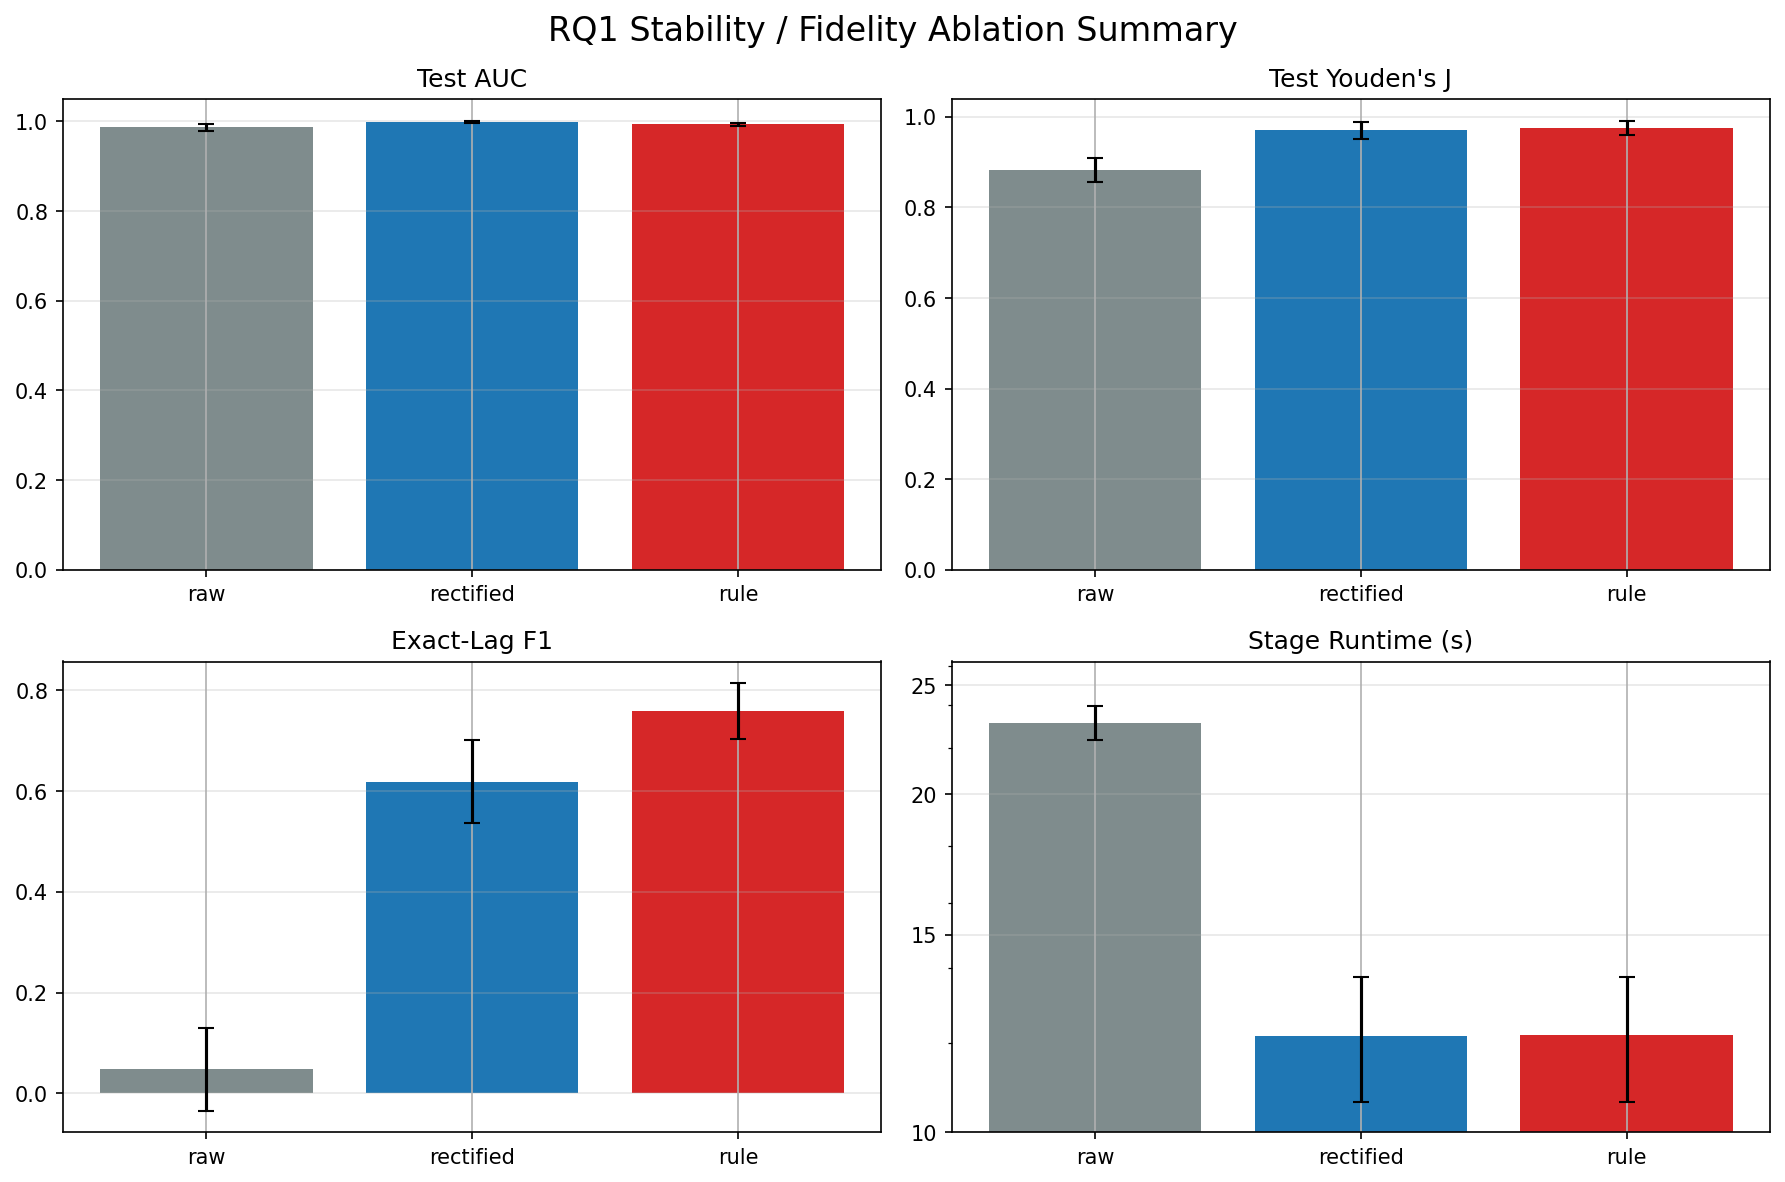

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\stability_ablation_summary.png


In [8]:
method_order = ["raw", "rectified", "rule"]
colors = {
    "raw": "#7f8c8d",
    "rectified": "#1f77b4",
    "rule": "#d62728",
}

plot_metrics = [
    ("auc_test", "Test AUC"),
    ("j_test", "Test Youden's J"),
    ("f1_exact", "Exact-Lag F1"),
    ("t_stage", "Stage Runtime (s)"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, (metric, label) in zip(axes, plot_metrics):
    grouped = runs_df.groupby("method")[metric].agg(["mean", "std"]).reindex(method_order)
    x = np.arange(len(grouped))
    ax.bar(
        x,
        grouped["mean"].to_numpy(),
        yerr=grouped["std"].fillna(0.0).to_numpy(),
        color=[colors[m] for m in method_order],
        capsize=4,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(method_order)
    ax.set_title(label)
    if metric == "t_stage":
        ax.set_yscale("log")
        runtime_lower = float((grouped["mean"] - grouped["std"].fillna(0.0)).clip(lower=0.0).min())
        runtime_upper = float((grouped["mean"] + grouped["std"].fillna(0.0)).max())
        runtime_step = 5
        tick_start = max(runtime_step, math.floor(runtime_lower / runtime_step) * runtime_step)
        tick_stop = max(tick_start + runtime_step, math.ceil(runtime_upper / runtime_step) * runtime_step)
        ax.set_ylim(max(runtime_lower * 0.95, 0.1), tick_stop * 1.05)
        ax.set_yticks(np.arange(tick_start, tick_stop + runtime_step, runtime_step))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g"))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("RQ1 Stability / Fidelity Ablation Summary", fontsize=16, y=0.98)
fig.tight_layout()
out_path = FIGURES_DIR / "stability_ablation_summary.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)


method jaccard_exact                          jaccard_near            \
                      mean       std  min       max         mean       std   
0        raw      0.055556  0.096225  0.0  0.166667     0.055556  0.096225   
1  rectified      0.451852  0.089810  0.4  0.555556     0.451852  0.089810   
2       rule      0.600000  0.346410  0.4  1.000000     0.600000  0.346410   

                  
   min       max  
0  0.0  0.166667  
1  0.4  0.555556  
2  0.4  1.000000

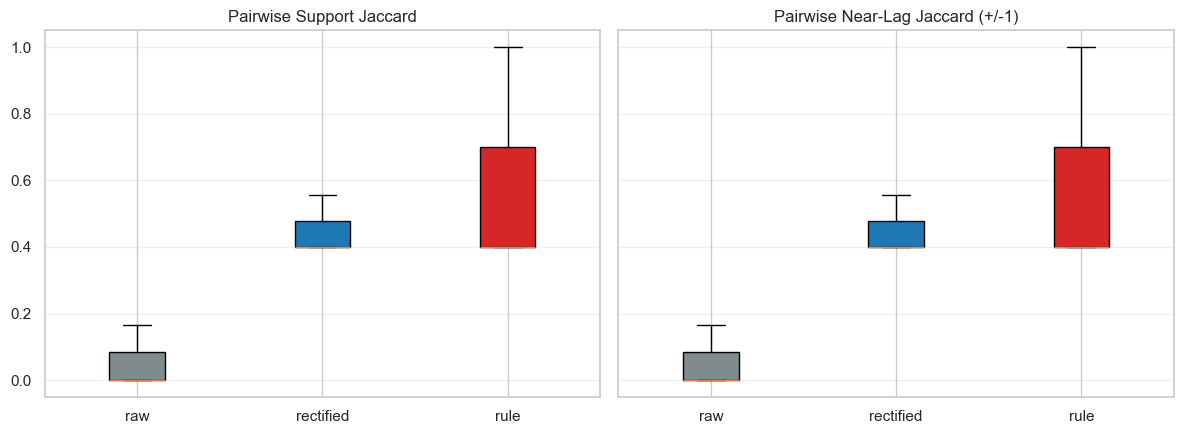

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\stability_pairwise_jaccard.png


In [9]:
pairwise_rows = []
for method in method_order:
    method_df = runs_df[runs_df["method"] == method].copy()
    supports = {int(row.seed): decode_support(row.selected_features) for row in method_df.itertuples()}
    for (seed_a, support_a), (seed_b, support_b) in itertools.combinations(sorted(supports.items()), 2):
        pairwise_rows.append(
            dict(
                method=method,
                seed_a=seed_a,
                seed_b=seed_b,
                jaccard_exact=support_jaccard(support_a, support_b),
                jaccard_near=support_jaccard_near(support_a, support_b, tol=1),
            )
        )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df.to_csv(RUN_DIR / "stability_pairwise_jaccard.csv", index=False)

stability_table = (
    pairwise_df.groupby("method")[["jaccard_exact", "jaccard_near"]]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
stability_table.to_csv(RUN_DIR / "stability_pairwise_summary.csv", index=False)

if display is not None:
    display(stability_table)
else:
    print(stability_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, metric, title in zip(
    axes,
    ["jaccard_exact", "jaccard_near"],
    ["Pairwise Support Jaccard", "Pairwise Near-Lag Jaccard (+/-1)"],
):
    series = [pairwise_df.loc[pairwise_df["method"] == method, metric].to_numpy() for method in method_order]
    bp = ax.boxplot(series, tick_labels=method_order, patch_artist=True)
    for patch, method in zip(bp["boxes"], method_order):
        patch.set_facecolor(colors[method])
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
out_path = FIGURES_DIR / "stability_pairwise_jaccard.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)


### Interpreting Pairwise Support Jaccard

Pairwise support Jaccard measures how much two runs agree on the selected feature-lag support. For two resamples with selected supports $S_a$ and $S_b$, the score is
$$
J(S_a,S_b)=\frac{|S_a \cap S_b|}{|S_a \cup S_b|}.
$$
A value of 1 means the two runs selected the same support, while 0 means they selected disjoint supports. The near-lag version applies the same idea after allowing a selected lag to match a neighboring lag within the reported tolerance.

This matters because RQ1 is about reliable attribution, not just discrimination. A model can achieve high AUC while selecting different correlated lag surrogates on each resample; that would make the support difficult to trust, audit, or compress into a stable rule. Higher pairwise Jaccard indicates that the pipeline repeatedly returns to the same explanatory feature-lag structure, which is the behavior expected when rectification reduces support ambiguity in the threshold-and-lag setting.


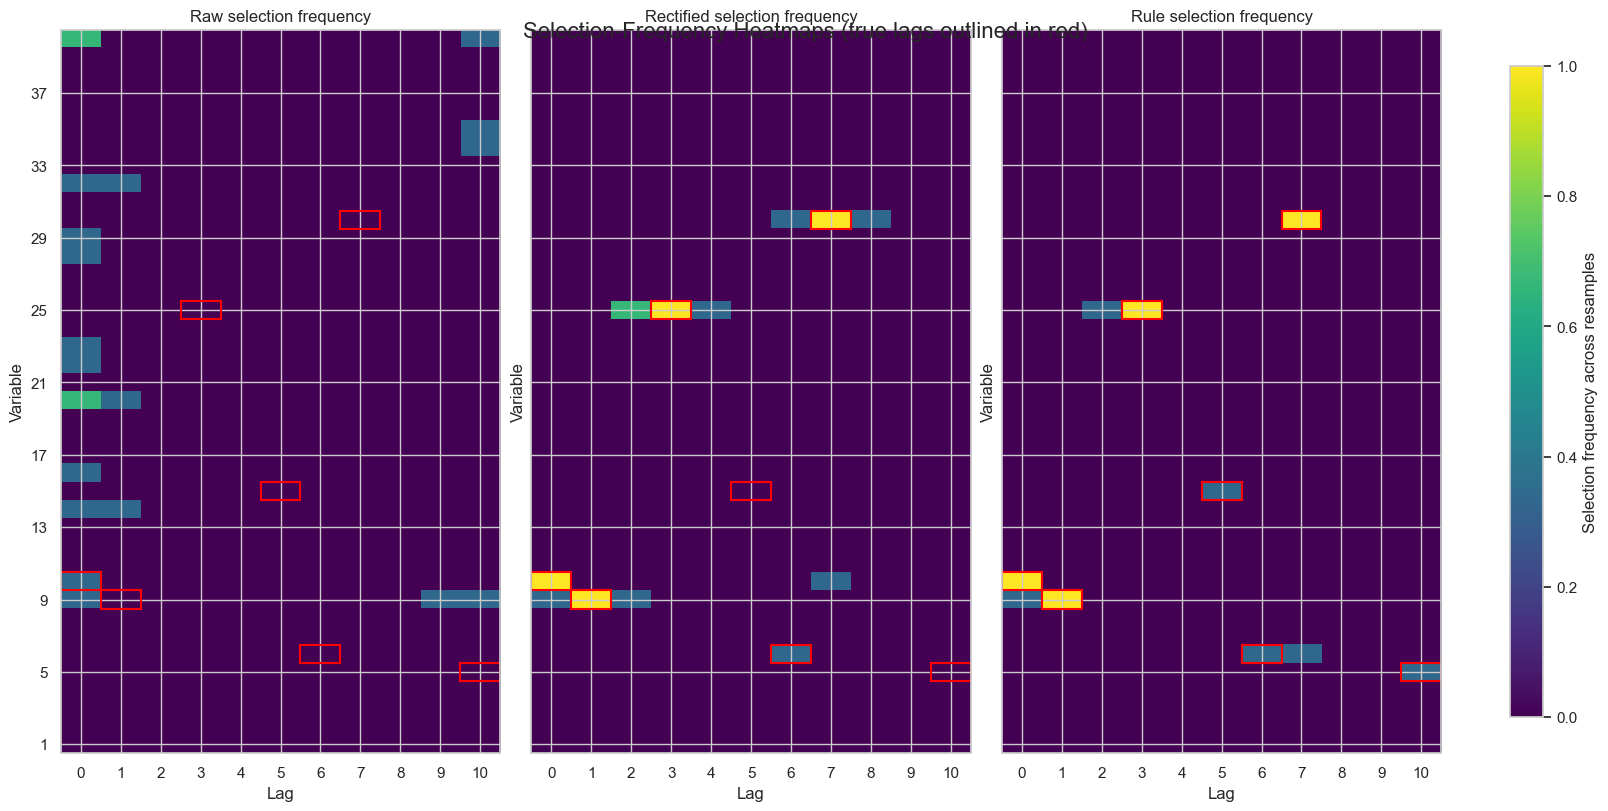

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\stability_selection_frequency.png


In [10]:
heatmap_supports = {}
for method in method_order:
    method_df = runs_df[runs_df["method"] == method].copy()
    heatmap_supports[method] = [decode_support(value) for value in method_df["selected_features"].tolist()]

grids = {
    method: support_frequency_grid(supports, n_variables=BASE_CONFIG["S"], h=BASE_CONFIG["H"])
    for method, supports in heatmap_supports.items()
}

for method, grid in grids.items():
    pd.DataFrame(grid).to_csv(RUN_DIR / f"selection_frequency_{method}.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True, constrained_layout=True)
vmin, vmax = 0.0, 1.0
for ax, method in zip(axes, method_order):
    grid = grids[method]
    image = ax.imshow(grid, aspect="auto", origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
    ax.set_title(f"{method.capitalize()} selection frequency")
    ax.set_xlabel("Lag")
    ax.set_xticks(range(BASE_CONFIG["H"] + 1))
    ax.set_ylabel("Variable")
    ax.set_yticks(np.arange(0, BASE_CONFIG["S"], 4))
    ax.set_yticklabels(np.arange(1, BASE_CONFIG["S"] + 1, 4))

    for feature in TRUE_FEATURES:
        parsed = parse_feature(feature)
        if parsed is None:
            continue
        variable, lag = parsed
        ax.add_patch(
            Rectangle(
                (lag - 0.5, variable - 1 - 0.5),
                1,
                1,
                fill=False,
                edgecolor="red",
                linewidth=1.5,
            )
        )

cbar = fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("Selection frequency across resamples")
fig.suptitle("Selection-Frequency Heatmaps (true lags outlined in red)", fontsize=16, y=0.98)
out_path = FIGURES_DIR / "stability_selection_frequency.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)


## Runtime Scaling Under Lag Expansion

This section isolates the computational trend under increasing lag expansion. To keep the timing sweep practical, it uses the lighter local `build_model(...)` routine instead of the more expensive external-CV wrapper used in the main ablation study. The point here is trend shape under growing feature count, not final model-selection policy.


In [11]:
def run_or_load_scaling(overwrite_cache: bool = False) -> pd.DataFrame:
    cache_path = RUN_DIR / "lag_scaling_runs.csv"
    if cache_path.exists() and not overwrite_cache:
        df = pd.read_csv(cache_path)
        print("Loaded cached lag-scaling results from:", cache_path)
        return df

    rows = []
    for h in LAG_SCALING_H:
        cfg = dict(SCALE_CONFIG)
        cfg["H"] = int(h)
        cfg["rseed"] = int(LAG_SCALING_SEED)

        t0 = time.perf_counter()
        _, train_df, test_df = syn.generate_synthetic_dataset_nexamples(**cfg)
        t_generate = time.perf_counter() - t0

        groups = skcase.organize(train_df)
        t1 = time.perf_counter()
        rt_train, limits = skcase.rectify_fast(train_df, groups, limits=None, sdfilter=3.0, snap=0.001)
        rt_test, _ = skcase.rectify_fast(test_df, groups, limits=limits, sdfilter=3.0, snap=0.001)
        t_rectify = time.perf_counter() - t1

        raw_train = train_df[[c for c in train_df.columns if c not in skcase.EXCLUDE_COLS]]

        t2 = time.perf_counter()
        skcase.build_model(raw_train, use_scaler=True, **SCALE_MODEL_KW)
        t_raw_fit = time.perf_counter() - t2

        t3 = time.perf_counter()
        skcase.build_model(rt_train, use_scaler=False, **SCALE_MODEL_KW)
        t_rectified_fit = time.perf_counter() - t3

        rows.append(
            dict(
                H=h,
                n_features=BASE_CONFIG["S"] * (h + 1),
                t_generate=float(t_generate),
                t_rectify=float(t_rectify),
                t_raw_fit=float(t_raw_fit),
                t_rectified_fit=float(t_rectified_fit),
            )
        )
        print(f"Completed lag scaling point H={h}")

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    print("Saved lag-scaling results to:", cache_path)
    return df


scaling_df = run_or_load_scaling(overwrite_cache=OVERWRITE_CACHE)
if display is not None:
    display(scaling_df)
else:
    print(scaling_df.to_string(index=False))


Loaded cached lag-scaling results from: C:\Users\jason\ODU\dissertation\notebooks\runs_new\stability_ablation\lag_scaling_runs.csv


,H,n_features,t_generate,t_rectify,t_raw_fit,t_rectified_fit
0,10,440,0.453116,0.014560,2.240656,1.192724
1,15,640,0.564255,0.022083,2.948499,1.648545
2,20,840,0.527124,0.033921,4.350901,2.301805


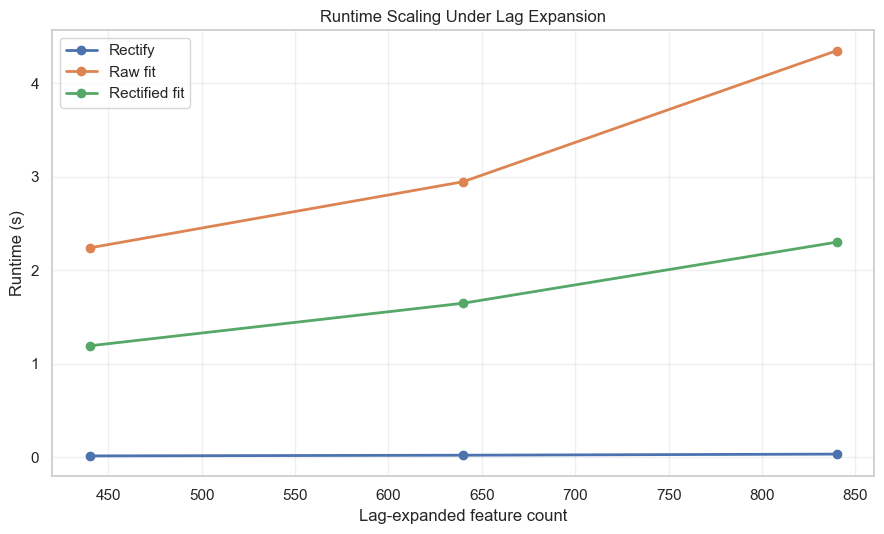

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\lag_runtime_scaling.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(scaling_df["n_features"], scaling_df["t_rectify"], marker="o", linewidth=2, label="Rectify")
ax.plot(scaling_df["n_features"], scaling_df["t_raw_fit"], marker="o", linewidth=2, label="Raw fit")
ax.plot(scaling_df["n_features"], scaling_df["t_rectified_fit"], marker="o", linewidth=2, label="Rectified fit")
ax.set_xlabel("Lag-expanded feature count")
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime Scaling Under Lag Expansion")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
out_path = FIGURES_DIR / "lag_runtime_scaling.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)


## Artifact Summary

The notebook writes the core artifacts to:

- `notebooks/runs_new/stability_ablation/stability_ablation_runs.csv`
- `notebooks/runs_new/stability_ablation/stability_ablation_summary_numeric.csv`
- `notebooks/runs_new/stability_ablation/stability_ablation_summary_formatted.csv`
- `notebooks/runs_new/stability_ablation/stability_ablation_deltas.csv`
- `notebooks/runs_new/stability_ablation/stability_pairwise_jaccard.csv`
- `notebooks/runs_new/stability_ablation/stability_pairwise_summary.csv`
- `notebooks/runs_new/stability_ablation/lag_scaling_runs.csv`

and saves figures into `notebooks/Figures/`:

- `stability_ablation_summary.png`
- `stability_pairwise_jaccard.png`
- `stability_selection_frequency.png`
- `lag_runtime_scaling.png`
